In [5]:
%pip install matplotlib
%pip install torch


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe -m pip install --upgrade pip' command.


Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 241.2/241.2 MB 4.7 MB/s eta 0:00:00
     -------------------------------------- 134.9/134.9 KB 7.8 MB/s eta 0:00:00
     ---------------------------------------- 6.3/6.3 MB 4.2 MB/s eta 0:00:00
     -------------------------------------- 201.0/201.0 KB 2.4 MB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 3.4 MB/s eta 0:00:00
     -------------------------------------- 536.2/536.2 KB 5.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe -m pip install --upgrade pip' command.


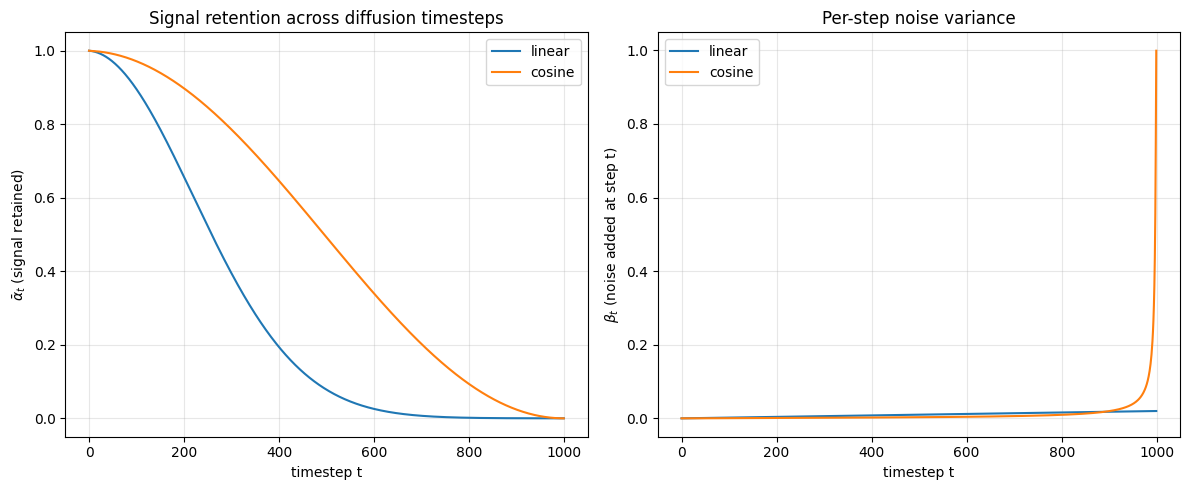

Linear   - alpha_bar at t=500: 0.0778
Cosine   - alpha_bar at t=500: 0.4921


In [6]:
import sys
sys.path.append("..")  # so we can import from src/ when run from notebooks/

import matplotlib.pyplot as plt
from src.schedule import NoiseSchedule

T = 1000

linear_sched = NoiseSchedule(timesteps=T, schedule_type="linear")
cosine_sched = NoiseSchedule(timesteps=T, schedule_type="cosine")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: alpha_bar_t (signal retained) over time
axes[0].plot(linear_sched.alphas_cumprod.numpy(), label="linear")
axes[0].plot(cosine_sched.alphas_cumprod.numpy(), label="cosine")
axes[0].set_xlabel("timestep t")
axes[0].set_ylabel(r"$\bar{\alpha}_t$ (signal retained)")
axes[0].set_title("Signal retention across diffusion timesteps")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: beta_t (noise added at each step) over time
axes[1].plot(linear_sched.betas.numpy(), label="linear")
axes[1].plot(cosine_sched.betas.numpy(), label="cosine")
axes[1].set_xlabel("timestep t")
axes[1].set_ylabel(r"$\beta_t$ (noise added at step t)")
axes[1].set_title("Per-step noise variance")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/samples/schedule_comparison.png", dpi=150)
plt.show()

print(f"Linear   - alpha_bar at t=500: {linear_sched.alphas_cumprod[500]:.4f}")
print(f"Cosine   - alpha_bar at t=500: {cosine_sched.alphas_cumprod[500]:.4f}")